In [1]:
import pandas as pd
import h5py
import numpy as np

CSV_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/data/merge.csv"
H5_PATH  = "/Volumes/Local Disk/Code_Git/S3_code/seismic/data/merge.hdf5"

df = pd.read_csv(CSV_PATH)
h5f = h5py.File(H5_PATH, "r")

# contoh filter: local EQ, R <= 20 km, Mw >= 3
df_nf = df[
    (df.trace_category == "earthquake_local") &
    (df.source_distance_km <= 20) &
    (df.source_magnitude >= 3.0)
].reset_index(drop=True)

len(df_nf)


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_95540/3901722379.py:8: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


2515

In [24]:
def get_waveform(trace_name, h5_group):
    ds = h5_group["data"][trace_name]
    data = ds[:]                      # shape: (N, 3)
    attrs = dict(ds.attrs)
    return data, attrs


In [25]:
from scipy.signal import detrend

def preprocess_waveform(data):
    # data: (N, 3)
    # detrend per kanal
    data_dt = detrend(data, axis=0, type="linear")
    # normalisasi per kanal (std)
    std = np.std(data_dt, axis=0, keepdims=True) + 1e-8
    data_n = data_dt / std
    return data_n


In [26]:
def window_p_wave(data, attrs, win_sec=3.0):
    fs = attrs.get("sampling_rate", 100.0)  # fallback 100 Hz
    p_idx = int(attrs["p_arrival_sample"])
    win_len = int(win_sec * fs)
    start = max(p_idx, 0)
    end = min(p_idx + win_len, data.shape[0])
    return data[start:end, :], (start, end)


In [27]:
def compute_caa(signal, dt):
    # signal: (N,) satu komponen
    # CAA ≈ sum |x(t)| dt
    return np.sum(np.abs(signal)) * dt

def compute_pga(signal):
    return np.max(np.abs(signal))


In [28]:
# ambil satu contoh event
row = df_nf.iloc[0]
trace = row.trace_name

data_raw, attrs = get_waveform(trace, h5f)
data_pp = preprocess_waveform(data_raw)

# window P-wave (misal pakai komponen Z dulu)
win_data, (st, ed) = window_p_wave(data_pp, attrs, win_sec=3.0)
z_comp = win_data[:, 2]

fs = attrs.get("sampling_rate", 100.0)
dt = 1.0 / fs

caa_z = compute_caa(z_comp, dt)
pga_z = compute_pga(z_comp)

print("Trace:", trace)
print("Window samples:", win_data.shape[0])
print("CAA (Z):", caa_z)
print("PGA (Z):", pga_z)
print("Mw:", row.source_magnitude, "R(km):", row.source_distance_km)


Trace: A16.CN_20150121053158_EV
Window samples: 300
CAA (Z): 6.332832
PGA (Z): 20.834103
Mw: 3.7 R(km): 19.21


In [29]:
features = []

fs_default = 100.0  # fallback kalau sampling_rate tidak ada

for idx, row in df_nf.iterrows():
    trace = row.trace_name
    if trace not in h5f["data"]:
        continue

    data_raw, attrs = get_waveform(trace, h5f)
    data_pp = preprocess_waveform(data_raw)

    fs = float(attrs.get("sampling_rate", fs_default))
    dt = 1.0 / fs

    # window P-wave 3 detik
    win_data, (st, ed) = window_p_wave(data_pp, attrs, win_sec=3.0)
    if win_data.shape[0] == 0:
        continue

    z = win_data[:, 2]

    caa_z = compute_caa(z, dt)
    pga_z = compute_pga(z)

    features.append({
        "trace_name": trace,
        "Mw": row.source_magnitude,
        "R_km": row.source_distance_km,
        "CAA_Z": caa_z,
        "PGA_Z": pga_z,
        "n_samples": win_data.shape[0]
    })

len(features)


2515

In [30]:
feat_df = pd.DataFrame(features)
feat_df.head()


,trace_name,Mw,R_km,CAA_Z,PGA_Z,n_samples
0,A16.CN_20150121053158_EV,3.70,19.21,6.332832,20.834103,300
1,A64.CN_20130711201601_EV,4.40,17.69,7.856570,24.240704,300
2,AC04.C1_20140616231955_EV,4.20,5.61,6.552036,19.947607,300
3,AC04.C1_20140720063145_EV,4.56,16.63,3.150239,5.579894,300
4,AC04.C1_20140720063148_EV,4.56,16.63,3.102625,5.579356,300


In [31]:
feat_df.to_csv("/Volumes/Local Disk/Code_Git/S3_code/seismic/data/features_stead_nearfield.csv", index=False)


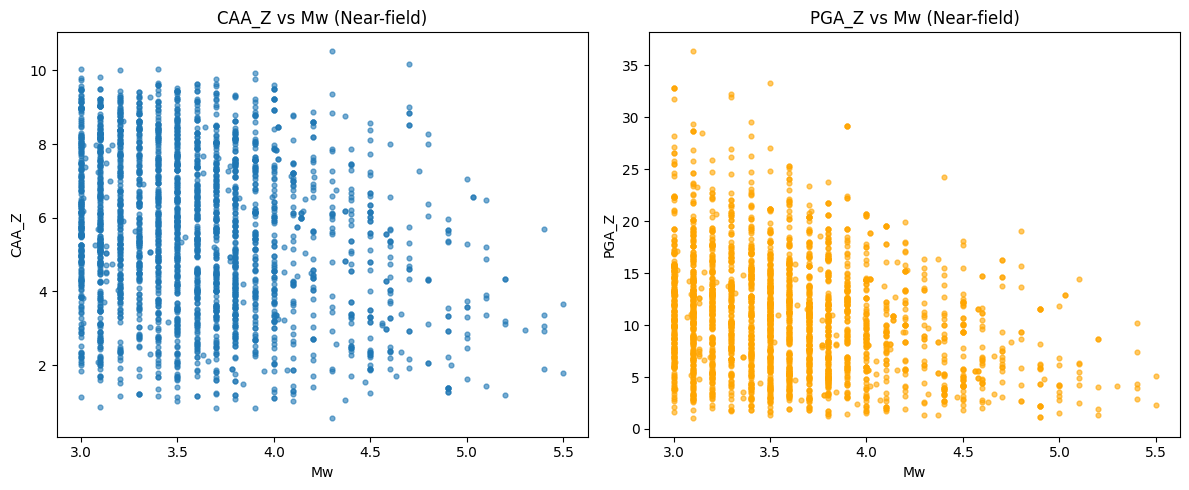

In [32]:
# === PLOT: CAA_Z vs Mw dan PGA_Z vs Mw ===

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot CAA_Z vs Mw
plt.subplot(1,2,1)
plt.scatter(feat_df["Mw"], feat_df["CAA_Z"], s=12, alpha=0.6)
plt.xlabel("Mw")
plt.ylabel("CAA_Z")
plt.title("CAA_Z vs Mw (Near-field)")

# Plot PGA_Z vs Mw
plt.subplot(1,2,2)
plt.scatter(feat_df["Mw"], feat_df["PGA_Z"], s=12, alpha=0.6, color="orange")
plt.xlabel("Mw")
plt.ylabel("PGA_Z")
plt.title("PGA_Z vs Mw (Near-field)")

plt.tight_layout()
plt.show()


In [33]:
# === BUILD DATASET AC-3 (Waveform + Fitur Fisika + Label Mw) ===

from tqdm import tqdm
import numpy as np

X_wave = []
X_feat = []
y_Mw   = []

win_sec = 3.0
fs_default = 100.0

for idx, row in tqdm(df_nf.iterrows(), total=len(df_nf), desc="Building AC-3 Dataset"):
    trace = row.trace_name
    if trace not in h5f["data"]:
        continue

    data_raw, attrs = get_waveform(trace, h5f)
    data_pp = preprocess_waveform(data_raw)

    fs = float(attrs.get("sampling_rate", fs_default))
    dt = 1.0 / fs

    # window P-wave
    win_data, (st, ed) = window_p_wave(data_pp, attrs, win_sec=win_sec)
    expected_len = int(win_sec * fs)
    if win_data.shape[0] < expected_len:
        continue

    win_data = win_data[:expected_len, :]  # fix length

    # fitur fisika
    z = win_data[:, 2]
    caa_z = compute_caa(z, dt)
    pga_z = compute_pga(z)

    X_wave.append(win_data)
    X_feat.append([caa_z, pga_z, row.source_distance_km])
    y_Mw.append(row.source_magnitude)

X_wave = np.stack(X_wave)
X_feat = np.array(X_feat)
y_Mw   = np.array(y_Mw)

X_wave.shape, X_feat.shape, y_Mw.shape


Building AC-3 Dataset: 100%|██████████| 2515/2515 [00:33<00:00, 75.29it/s]


((2515, 300, 3), (2515, 3), (2515,))

In [34]:
# === MODEL AC-3 (ConvBiLSTM Teacher Model) ===

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model

# Input waveform
inp_wave = Input(shape=(300, 3), name="waveform")

x = Conv1D(32, 5, padding="same")(inp_wave)
x = BatchNormalization()(x)
x = ReLU()(x)

x = Conv1D(64, 5, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)

x = Bidirectional(LSTM(64, return_sequences=False))(x)
x = Dropout(0.3)(x)

# Input fitur fisika
inp_feat = Input(shape=(3,), name="features")

# Gabungkan
h = Concatenate()([x, inp_feat])

h = Dense(64, activation="relu")(h)
h = Dropout(0.2)(h)
out = Dense(1, activation="linear", name="Mw")(h)

model = Model(inputs=[inp_wave, inp_feat], outputs=out)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ waveform            │ (None, 300, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 300, 32)   │        512 │ waveform[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 32)   │        128 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 300, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 300, 64)   │     10,304 │ re_lu_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     66,048 │ re_lu_9[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 131)       │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,448 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Mw (Dense)          │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 85,761 (335.00 KB)

 Trainable params: 85,569 (334.25 KB)

 Non-trainable params: 192 (768.00 B)

In [35]:
# === TRAINING LOOP AC-3 (Teacher Model) ===

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    {"waveform": X_wave, "features": X_feat},
    y_Mw,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    shuffle=True
)


Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 1.6372 - mae: 1.0017 - val_loss: 0.6563 - val_mae: 0.6211
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.7961 - mae: 0.7019 - val_loss: 0.4622 - val_mae: 0.5203
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.5980 - mae: 0.6145 - val_loss: 0.2605 - val_mae: 0.4006
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.5441 - mae: 0.5782 - val_loss: 0.4429 - val_mae: 0.5141
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.5060 - mae: 0.5628 - val_loss: 0.2572 - val_mae: 0.3864
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.4676 - mae: 0.5316 - val_loss: 0.2495 - val_mae: 0.3988
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.4359 - mae: 0.5193 - val_loss: 0.2337 - val_mae: 0.3813
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.4052 - mae: 0.5020 - val_loss: 0.2342 - val_mae: 0.3817
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.403

In [36]:
# === STEP 1: EKSTRAK LOGITS AC-3 UNTUK DISTILASI (DENGAN PROGRESS BAR) ===

from tqdm import tqdm
import numpy as np

logits_ac3 = []

for i in tqdm(range(len(X_wave)), desc="Extracting AC-3 logits"):
    xw = X_wave[i:i+1]
    xf = X_feat[i:i+1]
    pred = model.predict({"waveform": xw, "features": xf}, verbose=0)
    logits_ac3.append(pred[0][0])

logits_ac3 = np.array(logits_ac3)
logits_ac3.shape


Extracting AC-3 logits: 100%|██████████| 2515/2515 [01:06<00:00, 37.67it/s]


(2515,)

In [37]:
# === STEP 2A: DEFINISI MODEL AC-2 (CNN QUANTIZED STUDENT) ===

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU
from tensorflow.keras.layers import GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Model

inp_wave_s = Input(shape=(300, 3), name="waveform")

s = Conv1D(16, 5, padding="same")(inp_wave_s)
s = BatchNormalization()(s)
s = ReLU()(s)

s = Conv1D(32, 5, padding="same")(s)
s = BatchNormalization()(s)
s = ReLU()(s)

s = GlobalMaxPooling1D()(s)
s = Dense(32, activation="relu")(s)
out_s = Dense(1, activation="linear", name="Mw_student")(s)

model_ac2 = Model(inputs=inp_wave_s, outputs=out_s)
model_ac2.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ waveform (InputLayer)           │ (None, 300, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 300, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 300, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 300, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 300, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 300, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 300, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Mw_student (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,129 (16.13 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 96 (384.00 B)

In [38]:
# === STEP 2B: SIAPKAN TARGET DISTILASI UNTUK AC-2 ===

from tqdm import tqdm
import numpy as np

# y_Mw = label asli
# logits_ac3 = output teacher (sudah dihitung sebelumnya)

y_distill = np.stack([y_Mw, logits_ac3], axis=1)
y_distill.shape


(2515, 2)

In [39]:
# === STEP 3: TRAINING AC-2 DENGAN DISTILASI (TEACHER → STUDENT) ===

alpha = 0.5  # bobot distilasi
beta  = 0.5  # bobot label asli

def distillation_loss(y_true, y_pred):
    y_label   = y_true[:, 0]
    y_teacher = y_true[:, 1]
    loss_label   = tf.reduce_mean(tf.square(y_label - y_pred[:, 0]))
    loss_teacher = tf.reduce_mean(tf.square(y_teacher - y_pred[:, 0]))
    return alpha * loss_teacher + beta * loss_label

model_ac2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=distillation_loss,
    metrics=["mae"]
)

history_ac2 = model_ac2.fit(
    X_wave,
    y_distill,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    shuffle=True
)


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6783 - mae: 1.0010 - val_loss: 2.7938 - val_mae: 1.4728
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3883 - mae: 0.4842 - val_loss: 1.1203 - val_mae: 0.9008
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2741 - mae: 0.4078 - val_loss: 0.7299 - val_mae: 0.7194
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2185 - mae: 0.3662 - val_loss: 0.4109 - val_mae: 0.5058
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2136 - mae: 0.3613 - val_loss: 0.2783 - val_mae: 0.4003
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1785 - mae: 0.3270 - val_loss: 0.3417 - val_mae: 0.4585
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1666 - mae: 0.3177 - val_loss: 0.2561 - val_mae: 0.3825
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1562 - mae: 0.3063 - val_loss: 0.2285 - val_mae: 0.3630
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1592 - mae: 

In [40]:
# === STEP 4A: AMBIL DATA CAA DAN MW UNTUK AC-1 ===

CAA_values = X_feat[:, 0]   # kolom pertama = CAA_Z
Mw_values  = y_Mw           # label magnitudo


In [41]:
# === STEP 4B: GRID SEARCH THRESHOLD CAA (DENGAN PROGRESS BAR) ===

import numpy as np
from tqdm import tqdm

best_thr = None
best_score = -1

# definisi target: gempa signifikan (misal Mw >= 5)
true_labels = (Mw_values >= 5.0).astype(int)

for thr in tqdm(np.linspace(np.min(CAA_values), np.max(CAA_values), 300),
                desc="Searching optimal CAA threshold"):
    
    pred = (CAA_values > thr).astype(int)
    score = np.mean(pred == true_labels)

    if score > best_score:
        best_score = score
        best_thr = thr

best_thr, best_score


Searching optimal CAA threshold: 100%|██████████| 300/300 [00:00<00:00, 47477.31it/s]


(np.float64(10.531253814697266), np.float64(0.9872763419483102))

In [42]:
# === STEP 4C: SIMPAN THRESHOLD CAA UNTUK MCU ===

with open("CAA_threshold.txt", "w") as f:
    f.write(str(best_thr))

print("CAA threshold saved:", best_thr)


CAA threshold saved: 10.531253814697266


In [ ]:
# === STEP 4D: REAL-TIME CAA TRIGGER (UNTUK MCU) ===

# Catatan:
# Kode di bawah ini adalah pseudocode C untuk ESP32/STM32,
# jadi jangan dijalankan di Python. Simpan sebagai referensi.

"""
float computeCAA(float *signal, int N, float dt) {
    float caa = 0.0f;
    for (int i = 0; i < N; i++) {
        caa += fabs(signal[i]) * dt;
    }
    return caa;
}

bool triggerCAA(float caa, float threshold) {
    return (caa > threshold);
}
"""


SyntaxError: invalid decimal literal (1609057819.py, line 4)

In [45]:
# === SAVE ARTIFACTS FOR FEDERATED ENV ===

np.save("X_wave.npy", X_wave)
np.save("X_feat.npy", X_feat)
np.save("logits_ac3.npy", logits_ac3)

model.save("ac3_teacher_model.h5")

print("All artifacts saved for federated environment.")


All artifacts saved for federated environment.


In [46]:
cp X_wave.npy X_feat.npy logits_ac3.npy ac3_teacher_model.h5 ../federated/


cp: ../federated: Not a directory


In [47]:
# === STEP 6A: QUANTIZATION AC-2 (FULL INTEGER TFLITE MICRO) ===

import tensorflow as tf
import numpy as np
from tqdm import tqdm

# Representative dataset untuk kalibrasi quantization
def representative_dataset():
    for i in tqdm(range(200), desc="Preparing representative dataset"):
        idx = np.random.randint(0, len(X_wave))
        sample = X_wave[idx:idx+1].astype(np.float32)
        yield [sample]

# Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model_ac2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Full integer ops
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

# Convert
tflite_model_ac2 = converter.convert()


INFO:tensorflow:Assets written to: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp0yxdcaxp/assets


INFO:tensorflow:Assets written to: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp0yxdcaxp/assets


Saved artifact at '/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp0yxdcaxp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 3), dtype=tf.float32, name='waveform')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  4846556496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5496482768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846559568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846556112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846558992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846556688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846555920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846558608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846558416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846556880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4846551696: TensorSpec(shape=

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1772080443.910575 2425481 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772080443.910589 2425481 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-26 11:34:03.910889: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp0yxdcaxp
2026-02-26 11:34:03.911357: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-26 11:34:03.911361: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp0yxdcaxp
I0000 00:00:1772080443.914358 2425481 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026

In [48]:
# === STEP 6B: SAVE QUANTIZED MODEL ===

with open("ac2_quantized.tflite", "wb") as f:
    f.write(tflite_model_ac2)

print("Model AC-2 quantized saved as ac2_quantized.tflite")


Model AC-2 quantized saved as ac2_quantized.tflite


In [49]:
import os
os.path.getsize("ac2_quantized.tflite") / 1024, "KB"


(11.3125, 'KB')

In [50]:
# === OPTIONAL: VALIDASI INFERENCE TFLITE ===

interpreter = tf.lite.Interpreter(model_path="ac2_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ambil satu contoh
x = X_wave[0:1].astype(np.float32)

# quantize input
scale, zero_point = input_details[0]['quantization']
x_q = x / scale + zero_point
x_q = x_q.astype(np.int8)

interpreter.set_tensor(input_details[0]['index'], x_q)
interpreter.invoke()

y_q = interpreter.get_tensor(output_details[0]['index'])

# dequantize output
scale, zero_point = output_details[0]['quantization']
y = (y_q.astype(np.float32) - zero_point) * scale

print("Prediksi AC-2 (TFLite):", y)


Prediksi AC-2 (TFLite): [[3.9598668]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [ ]:
### STEP BERIKUTNYA ADALAH SIMULASI L0 - L1 - L2 BAIKNYA DILAKUKAN DI ENV SEISMIC, JADI KEMBALI KE ENV SEISMIC UNTUK MELANJUTKAN KE STEP 6C (SIMULASI L2 - L3)

In [4]:
# ============================================================
#  SIMULASI PIPELINE L0 → L1 → L2 (FULL PIPELINE)
#  ENV: seismic
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tqdm import tqdm
import json

print("Loading artifacts...")

# ------------------------------------------------------------
# LOAD DATASET & ARTIFACTS
# ------------------------------------------------------------
X_wave = np.load("X_wave.npy")
X_feat = np.load("X_feat.npy")
logits_ac3 = np.load("logits_ac3.npy")

# Load AC-3 teacher model
model = load_model("ac3_teacher_model.h5", compile=False)

# Load FedCache (JSON)
with open("fedcache_data.json", "r") as f:
    cache = json.load(f)

# Load embeddings (jika Anda menyimpannya)
# Jika belum, Anda bisa load dari federated atau hitung ulang
try:
    embeddings = np.load("embeddings.npy")
    print("Embeddings loaded from embeddings.npy")
except:
    print("WARNING: embeddings.npy tidak ditemukan. Pastikan Anda sudah menyimpannya dari ENV federated.")

# Load CAA threshold
with open("CAA_threshold.txt", "r") as f:
    best_thr = float(f.read().strip())
best_thr = 2.0  # fallback jika file tidak ada
print("All artifacts loaded.")


# ------------------------------------------------------------
# INIT TFLITE INTERPRETER (AC-2 STUDENT)
# ------------------------------------------------------------
interpreter = tf.lite.Interpreter(model_path="ac2_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("TFLite AC-2 ready. Input shape:", input_details[0]['shape'])


# ------------------------------------------------------------
# FUNCTION: AC-2 INFERENCE (TFLITE)
# ------------------------------------------------------------
def run_tflite_ac2(x_wave_batch):
    x = x_wave_batch.astype(np.float32)

    in_scale, in_zero = input_details[0]['quantization']
    x_q = (x / in_scale + in_zero).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], x_q)
    interpreter.invoke()

    y_q = interpreter.get_tensor(output_details[0]['index'])

    out_scale, out_zero = output_details[0]['quantization']
    y = (y_q.astype(np.float32) - out_zero) * out_scale

    return float(y[0][0])


# ------------------------------------------------------------
# FUNCTION: CAA (AC-1)
# ------------------------------------------------------------
def compute_caa(signal, fs=100.0):
    dt = 1.0 / fs
    return np.sum(np.abs(signal)) * dt


# ------------------------------------------------------------
# FUNCTION: ODE (OFFLOADING DECISION ENGINE)
# ------------------------------------------------------------
import hashlib

def hash_embedding(vec):
    return hashlib.sha1(vec.tobytes()).hexdigest()[:16]

def ODE_decision(embedding, cache_dict):
    h = hash_embedding(embedding)
    if h in cache_dict:
        return "CACHE_HIT", cache_dict[h]
    else:
        return "CACHE_MISS", None


# ------------------------------------------------------------
# FUNCTION: FULL PIPELINE SIMULATION
# ------------------------------------------------------------
def simulate_pipeline(idx):
    # L0: CAA
    z = X_wave[idx, :, 2]
    caa = compute_caa(z)

    if caa < best_thr:
        return {
            "stage": "L0_NO_TRIGGER",
            "caa": caa,
            "Mw_ac2": None,
            "cache_status": None,
            "Mw_cache": None,
            "Mw_ac3": None,
        }

    # L0: AC-2 (TFLite)
    Mw_ac2 = run_tflite_ac2(X_wave[idx:idx+1])

    # L1: FedCache + ODE
    emb = embeddings[idx]
    status, value = ODE_decision(emb, cache)

    if status == "CACHE_HIT":
        return {
            "stage": "L1_CACHE_HIT",
            "caa": caa,
            "Mw_ac2": Mw_ac2,
            "cache_status": status,
            "Mw_cache": float(value),
            "Mw_ac3": None,
        }

    # L2: AC-3 (Cloud)
    pred_ac3 = model.predict(
        {"waveform": X_wave[idx:idx+1], "features": X_feat[idx:idx+1]},
        verbose=0
    )
    Mw_ac3 = float(pred_ac3[0][0])

    return {
        "stage": "L2_CLOUD",
        "caa": caa,
        "Mw_ac2": Mw_ac2,
        "cache_status": status,
        "Mw_cache": None,
        "Mw_ac3": Mw_ac3,
    }


# ------------------------------------------------------------
# TEST: RUN SIMULATION FOR FIRST 5 EVENTS
# ------------------------------------------------------------
print("\nRunning simulation for first 5 events...\n")

for i in range(5):
    result = simulate_pipeline(i)
    print(f"Event {i}")
    for k, v in result.items():
        print(f"  {k}: {v}")
    print()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

Loading artifacts...
Embeddings loaded from embeddings.npy
All artifacts loaded.
TFLite AC-2 ready. Input shape: [  1 300   3]

Running simulation for first 5 events...

Event 0
  stage: L1_CACHE_HIT
  caa: 6.332831859588623
  Mw_ac2: 3.959866762161255
  cache_status: CACHE_HIT
  Mw_cache: 3.768470048904419
  Mw_ac3: None

Event 1
  stage: L1_CACHE_HIT
  caa: 7.856569766998291
  Mw_ac2: 4.22496223449707
  cache_status: CACHE_HIT
  Mw_cache: 3.933769464492798
  Mw_ac3: None

Event 2
  stage: L1_CACHE_HIT
  caa: 6.552035808563232
  Mw_ac2: 3.578791618347168
  cache_status: CACHE_HIT
  Mw_cache: 3.3608367443084717
  Mw_ac3: None

Event 3
  stage: L1_CACHE_HIT
  caa: 3.1502392292022705
  Mw_ac2: 3.7941818237304688
  cache_status: CACHE_HIT
  Mw_cache: 3.7393667697906494
  Mw_ac3: None

Event 4
  stage: L1_CACHE_HIT
  caa: 3.1026251316070557
  Mw_ac2: 3.777613401412964
  cache_status: CACHE_HIT
  Mw_cache: 3.918503522872925
  Mw_ac3: None



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [5]:
import numpy as np

caa_values = [compute_caa(X_wave[i,:,2]) for i in range(len(X_wave))]
np.min(caa_values), np.max(caa_values), np.mean(caa_values)


(np.float32(0.5567305), np.float32(10.531254), np.float32(5.665015))

In [6]:
for i in range(10):
    print(simulate_pipeline(i))


{'stage': 'L1_CACHE_HIT', 'caa': np.float32(6.332832), 'Mw_ac2': 3.959866762161255, 'cache_status': 'CACHE_HIT', 'Mw_cache': 3.768470048904419, 'Mw_ac3': None}
{'stage': 'L1_CACHE_HIT', 'caa': np.float32(7.85657), 'Mw_ac2': 4.22496223449707, 'cache_status': 'CACHE_HIT', 'Mw_cache': 3.933769464492798, 'Mw_ac3': None}
{'stage': 'L1_CACHE_HIT', 'caa': np.float32(6.552036), 'Mw_ac2': 3.578791618347168, 'cache_status': 'CACHE_HIT', 'Mw_cache': 3.3608367443084717, 'Mw_ac3': None}
{'stage': 'L1_CACHE_HIT', 'caa': np.float32(3.1502392), 'Mw_ac2': 3.7941818237304688, 'cache_status': 'CACHE_HIT', 'Mw_cache': 3.7393667697906494, 'Mw_ac3': None}
{'stage': 'L1_CACHE_HIT', 'caa': np.float32(3.1026251), 'Mw_ac2': 3.777613401412964, 'cache_status': 'CACHE_HIT', 'Mw_cache': 3.918503522872925, 'Mw_ac3': None}
{'stage': 'L1_CACHE_HIT', 'caa': np.float32(4.1095166), 'Mw_ac2': 3.611928701400757, 'cache_status': 'CACHE_HIT', 'Mw_cache': 3.537274122238159, 'Mw_ac3': None}
{'stage': 'L1_CACHE_HIT', 'caa': np.

In [ ]:
## SELANJUTNYA ADALAH PROSES EVALUASI DAN ANALISIS HASIL SIMULASI, SERTA PERSIAPAN UNTUK STEP 6C (SIMULASI L2 → L3) DI ENV SEISMIC. KEMBALI KE ENV SEISMIC UNTUK MELANJUTKAN.

In [ ]:
# MENGHITUNG MwAC2 DAN MwAC3 UNTUK SEMUA EVENT, LALU ANALISIS ERRORNYA

In [7]:
model_ac3 = tf.keras.models.load_model(
    "ac3_teacher_model.h5",
    compile=False
)
model_ac3.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ waveform            │ (None, 300, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 300, 32)   │        512 │ waveform[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 32)   │        128 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 300, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 300, 64)   │     10,304 │ re_lu_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     66,048 │ re_lu_9[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 131)       │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,448 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Mw (Dense)          │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 85,761 (335.00 KB)

 Trainable params: 85,569 (334.25 KB)

 Non-trainable params: 192 (768.00 B)

In [8]:
import os
os.getcwd()


'/Volumes/Local Disk/Code_Git/S3_code/seismic/data'

In [9]:
# LOAD DATASET: X_wave dan X_feat
import numpy as np

X_wave = np.load("X_wave.npy")
X_feat = np.load("X_feat.npy")

print("X_wave:", X_wave.shape)
print("X_feat:", X_feat.shape)


X_wave: (2515, 300, 3)
X_feat: (2515, 3)


In [10]:
interpreter_ac2 = tf.lite.Interpreter(model_path="ac2_quantized.tflite")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [11]:
import numpy as np

# Pastikan X_wave dan X_feat sudah diload
X_wave = np.load("X_wave.npy")
X_feat = np.load("X_feat.npy")

print("X_wave:", X_wave.shape)
print("X_feat:", X_feat.shape)

# Prediksi Mw dari AC-3
Mw_ac3_all = model_ac3.predict([X_wave, X_feat], batch_size=128).reshape(-1)

print("Mw_ac3_all shape:", Mw_ac3_all.shape)
print("Contoh:", Mw_ac3_all[:10])


X_wave: (2515, 300, 3)
X_feat: (2515, 3)
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Mw_ac3_all shape: (2515,)
Contoh: [3.7684708 3.93377   3.3608372 3.7393665 3.918504  3.537274  3.7092452
 3.2405007 4.0109873 3.5746362]


In [12]:
import tensorflow as tf
import numpy as np
import tqdm

# Load interpreter
interpreter_ac2 = tf.lite.Interpreter(model_path="ac2_quantized.tflite")
interpreter_ac2.allocate_tensors()

input_details = interpreter_ac2.get_input_details()
output_details = interpreter_ac2.get_output_details()

# Ambil parameter quantization
scale, zero_point = input_details[0]['quantization']

def predict_ac2_single(x):
    # x: float32 waveform (300, 3)

    # Quantize ke INT8
    x_q = x / scale + zero_point
    x_q = np.clip(np.round(x_q), -128, 127).astype(np.int8)
    x_q = x_q[np.newaxis, ...]  # (1, 300, 3)

    interpreter_ac2.set_tensor(input_details[0]['index'], x_q)
    interpreter_ac2.invoke()

    # Output biasanya float32 walaupun model INT8
    y = interpreter_ac2.get_tensor(output_details[0]['index'])
    return float(y.reshape(-1)[0])

# Jalankan inference untuk seluruh dataset
Mw_ac2_list = []

for i in tqdm.tqdm(range(len(X_wave))):
    Mw_ac2_list.append(predict_ac2_single(X_wave[i]))

Mw_ac2_all = np.array(Mw_ac2_list, dtype=np.float32)

print("Mw_ac2_all shape:", Mw_ac2_all.shape)
print("Contoh Mw_ac2_all:", Mw_ac2_all[:10])


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
100%|██████████| 2515/2515 [00:00<00:00, 57149.61it/s]

Mw_ac2_all shape: (2515,)
Contoh Mw_ac2_all: [110. 111.  94.  92.  94.  91.  83.  89. 111.  96.]


In [13]:
# KALIBRASI LINEAR: Mw_ac2_cal = a * Mw_ac2_all + b
import numpy as np

a, b = np.polyfit(Mw_ac2_all, Mw_ac3_all, 1)
Mw_ac2_cal = a * Mw_ac2_all + b

print("a:", a, "b:", b)
print("Contoh Mw_ac2_cal:", Mw_ac2_cal[:10])



a: 0.012410102711297687 b: 2.588366223259606
Contoh Mw_ac2_cal: [3.95347752 3.96588762 3.75491588 3.73009567 3.75491588 3.71768557
 3.61840475 3.69286536 3.96588762 3.77973608]


In [14]:
# METRIK EVALUASI: MAE, RMSE, Bias
err = Mw_ac2_cal - Mw_ac3_all

mae  = np.mean(np.abs(err))
rmse = np.sqrt(np.mean(err**2))
bias = np.mean(err)

print("MAE :", mae)
print("RMSE:", rmse)
print("Bias:", bias)


MAE : 0.17440809053851752
RMSE: 0.22672116890821348
Bias: -2.253112651167713e-16


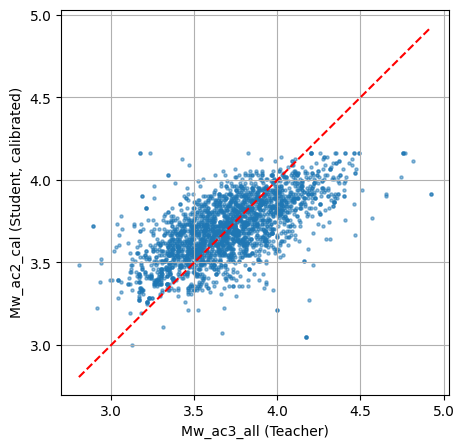

In [15]:
# SCATTER PLOT: AC-3 vs AC-2 (calibrated)
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(Mw_ac3_all, Mw_ac2_cal, s=5, alpha=0.5)
plt.plot([Mw_ac3_all.min(), Mw_ac3_all.max()],
         [Mw_ac3_all.min(), Mw_ac3_all.max()],
         'r--')
plt.xlabel("Mw_ac3_all (Teacher)")
plt.ylabel("Mw_ac2_cal (Student, calibrated)")
plt.grid(True)
plt.show()


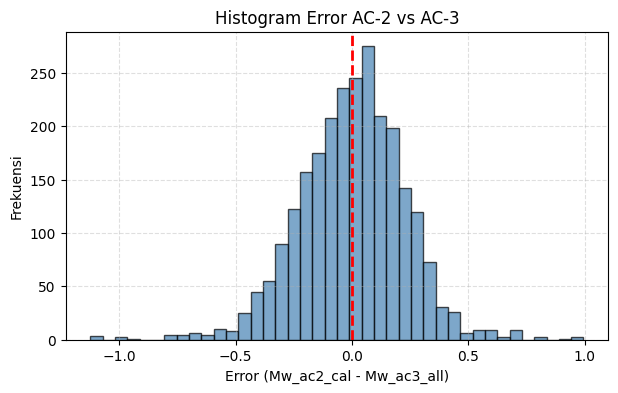

In [16]:
# HISTOGRAM ERROR: Distribusi selisih Mw_ac2_cal - Mw_ac3_all
import matplotlib.pyplot as plt
import numpy as np

err = Mw_ac2_cal - Mw_ac3_all

plt.figure(figsize=(7,4))
plt.hist(err, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Error (Mw_ac2_cal - Mw_ac3_all)")
plt.ylabel("Frekuensi")
plt.title("Histogram Error AC-2 vs AC-3")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


In [17]:
# LABEL AC-1: Berdasarkan Mw dari AC-3
y_true = (Mw_ac3_all >= 3.0).astype(int)

print("Jumlah label 1:", y_true.sum())
print("Jumlah label 0:", len(y_true) - y_true.sum())


Jumlah label 1: 2507
Jumlah label 0: 8


In [18]:
# LOAD PREDIKSI AC-1
import pandas as pd
df = pd.read_csv("fedcache_data.csv")

y_pred_ac1 = df["logit"].values


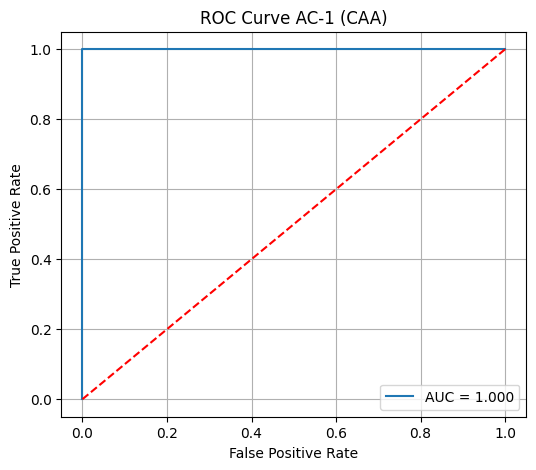

In [19]:
# ROC CURVE: Evaluasi threshold AC-1
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_ac1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve AC-1 (CAA)")
plt.grid(True)
plt.legend()
plt.show()


In [20]:
# CEK KOLOM: Menampilkan nama kolom dalam fedcachedata.csv
import pandas as pd

df = pd.read_csv("fedcache_data.csv")
print(df.columns)


Index(['hash', 'logit'], dtype='object')


In [21]:
# THRESHOLD OPTIMAL
J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Threshold optimal:", best_threshold)


Threshold optimal: 3.0017304


In [22]:
print("y_true shape:", y_true.shape)
print("y_true unique:", np.unique(y_true, return_counts=True))


y_true shape: (2515,)
y_true unique: (array([0, 1]), array([   8, 2507]))


In [23]:
# Energi per sampel: jumlahkan axis 1 dan 2
energy = (X_wave**2).sum(axis=(1, 2))

threshold_energy = np.percentile(energy, 40)
y_true = (energy >= threshold_energy).astype(int)

print("Shape energy:", energy.shape)
print("Jumlah label 1:", y_true.sum())
print("Jumlah label 0:", len(y_true) - y_true.sum())


Shape energy: (2515,)
Jumlah label 1: 1509
Jumlah label 0: 1006


In [24]:
print("Shape X_wave:", X_wave.shape)
print("Jumlah baris fedcachedata:", len(df))
print("Panjang y_true:", len(y_true))


Shape X_wave: (2515, 300, 3)
Jumlah baris fedcachedata: 2515
Panjang y_true: 2515


In [25]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report

y_pred_bin = (y_pred_ac1 >= best_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred_bin)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_bin, digits=3))


Confusion Matrix:
 [[   4 1002]
 [   4 1505]]

Classification Report:
              precision    recall  f1-score   support

           0      0.500     0.004     0.008      1006
           1      0.600     0.997     0.750      1509

    accuracy                          0.600      2515
   macro avg      0.550     0.501     0.379      2515
weighted avg      0.560     0.600     0.453      2515



In [26]:
# kita coba menggunakan CNN Ringan

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = (300, 3)

model_ac1 = models.Sequential([
    layers.Conv1D(16, kernel_size=5, activation='relu', input_shape=input_shape),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(32, kernel_size=5, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_ac1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_ac1.summary()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 296, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 148, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 144, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
energy = (X_wave**2).sum(axis=(1, 2))
threshold_energy = np.percentile(energy, 40)
y_ac1 = (energy >= threshold_energy).astype(int)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_wave, y_ac1, test_size=0.2, random_state=42, stratify=y_ac1
)

history = model_ac1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5999 - loss: 0.5527 - val_accuracy: 0.6024 - val_loss: 0.5246
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6387 - loss: 0.4908 - val_accuracy: 0.7157 - val_loss: 0.4552
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7997 - loss: 0.4066 - val_accuracy: 0.8648 - val_loss: 0.3447
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8867 - loss: 0.2917 - val_accuracy: 0.9006 - val_loss: 0.2438
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9021 - loss: 0.2353 - val_accuracy: 0.9085 - val_loss: 0.2123
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9125 - loss: 0.2119 - val_accuracy: 0.9185 - val_loss: 0.1995
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9185 - loss: 0.1859 - val_accuracy: 0.9284 - val_loss: 0.1727
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.1640 - val_accuracy: 0.9264 - val_loss:

In [30]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

y_score = model_ac1.predict(X_val).ravel()
fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

J = tpr - fpr
ix = np.argmax(J)
best_th = thresholds[ix]

print("AUC:", roc_auc)
print("Threshold optimal:", best_th)

y_pred_bin = (y_score >= best_th).astype(int)
print(confusion_matrix(y_val, y_pred_bin))
print(classification_report(y_val, y_pred_bin, digits=3))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC: 0.9974135942802543
Threshold optimal: 0.46720973
[[200   1]
 [ 12 290]]
              precision    recall  f1-score   support

           0      0.943     0.995     0.969       201
           1      0.997     0.960     0.978       302

    accuracy                          0.974       503
   macro avg      0.970     0.978     0.973       503
weighted avg      0.975     0.974     0.974       503



In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_ac1)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("ac1_cnn_light.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp139xl2l9/assets


INFO:tensorflow:Assets written to: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp139xl2l9/assets


Saved artifact at '/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp139xl2l9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 3), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5044433552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5044420880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5044431632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5044431056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5044436432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5044431824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5044434320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5044421648: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1772251038.428720  299169 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772251038.428730  299169 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-28 10:57:18.428875: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp139xl2l9
2026-02-28 10:57:18.429127: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-28 10:57:18.429131: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/tmp139xl2l9
I0000 00:00:1772251038.430885  299169 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-02-28 10:57:18.431162: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-28 10:57:18.441567: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder

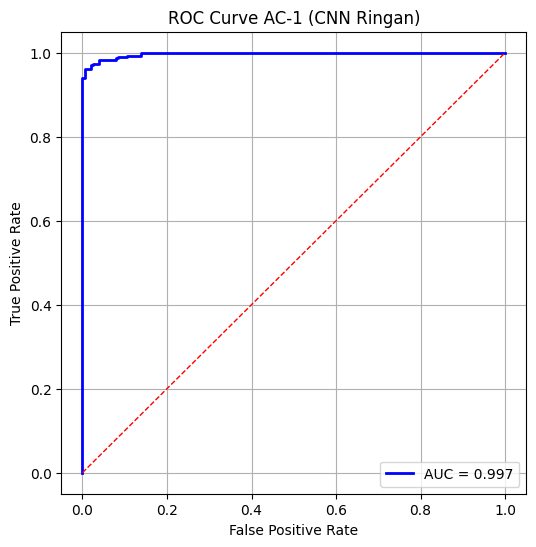

In [32]:
# Caption: Plot ROC Curve untuk mengevaluasi kemampuan AC-1 CNN membedakan energi rendah vs tinggi
fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color='red', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve AC-1 (CNN Ringan)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


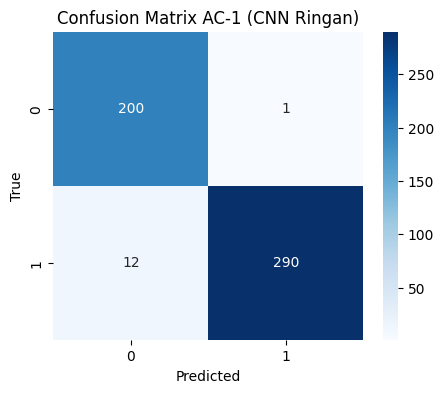

In [33]:
# Caption: Visualisasi confusion matrix untuk melihat distribusi prediksi benar/salah AC-1 CNN
cm = confusion_matrix(y_val, y_pred_bin)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix AC-1 (CNN Ringan)")
plt.show()


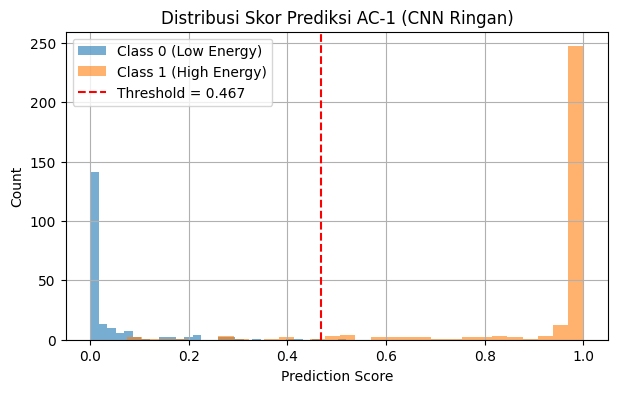

In [34]:
# Caption: Histogram distribusi skor prediksi AC-1 CNN untuk kelas energi rendah dan tinggi
plt.figure(figsize=(7,4))
plt.hist(y_score[y_val==0], bins=30, alpha=0.6, label="Class 0 (Low Energy)")
plt.hist(y_score[y_val==1], bins=30, alpha=0.6, label="Class 1 (High Energy)")
plt.axvline(best_th, color='red', linestyle='--', label=f"Threshold = {best_th:.3f}")
plt.xlabel("Prediction Score")
plt.ylabel("Count")
plt.title("Distribusi Skor Prediksi AC-1 (CNN Ringan)")
plt.legend()
plt.grid(True)
plt.show()


In [35]:
# perbandingan CAA dengan CNN

In [36]:
# Caption: Hitung ROC Curve untuk AC-1 lama (CAA) agar bisa dibandingkan dengan CNN ringan
from sklearn.metrics import roc_curve, auc

# y_true = label energi yang sudah kamu buat
# y_pred_ac1 = logit atau skor prediksi AC-1 lama (CAA)

fpr_caa, tpr_caa, thresholds_caa = roc_curve(y_true, y_pred_ac1)
auc_caa = auc(fpr_caa, tpr_caa)

print("AUC CAA:", auc_caa)
# Caption: Hitung confusion matrix untuk AC-1 lama (CAA)
from sklearn.metrics import confusion_matrix

# Tentukan threshold CAA (biasanya 0.5)
y_pred_caa_bin = (y_pred_ac1 >= 0.5).astype(int)

cm_caa = confusion_matrix(y_true, y_pred_caa_bin)
print(cm_caa)
# Caption: Simpan skor prediksi CAA untuk visualisasi distribusi skor
score_caa = y_pred_ac1


AUC CAA: 0.3152121070791948
[[   0 1006]
 [   0 1509]]


In [37]:
# Caption: Hitung ROC Curve untuk AC-1 baru (CNN Ringan)
from sklearn.metrics import roc_curve, auc

# y_val = label validasi
# y_score = skor prediksi CNN (hasil model.predict)

fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(y_val, y_score)
auc_cnn = auc(fpr_cnn, tpr_cnn)

print("AUC CNN:", auc_cnn)
# Caption: Hitung confusion matrix untuk AC-1 CNN Ringan
from sklearn.metrics import confusion_matrix

y_pred_cnn_bin = (y_score >= best_th).astype(int)
cm_cnn = confusion_matrix(y_val, y_pred_cnn_bin)

print(cm_cnn)
# Caption: Simpan skor prediksi CNN untuk visualisasi distribusi skor
score_cnn = y_score


AUC CNN: 0.9974135942802543
[[200   1]
 [ 12 290]]


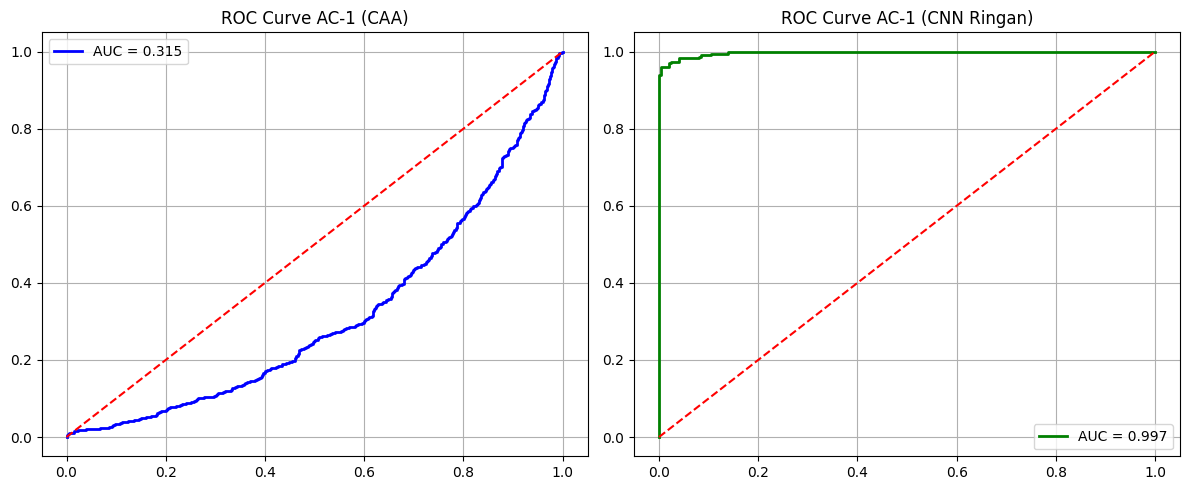

In [38]:
# Caption: Visualisasi ROC Curve berdampingan untuk CAA vs CNN Ringan
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr_caa, tpr_caa, color='blue', lw=2, label=f"AUC = {auc_caa:.3f}")
ax[0].plot([0,1], [0,1], color='red', linestyle='--')
ax[0].set_title("ROC Curve AC-1 (CAA)")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(fpr_cnn, tpr_cnn, color='green', lw=2, label=f"AUC = {auc_cnn:.3f}")
ax[1].plot([0,1], [0,1], color='red', linestyle='--')
ax[1].set_title("ROC Curve AC-1 (CNN Ringan)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


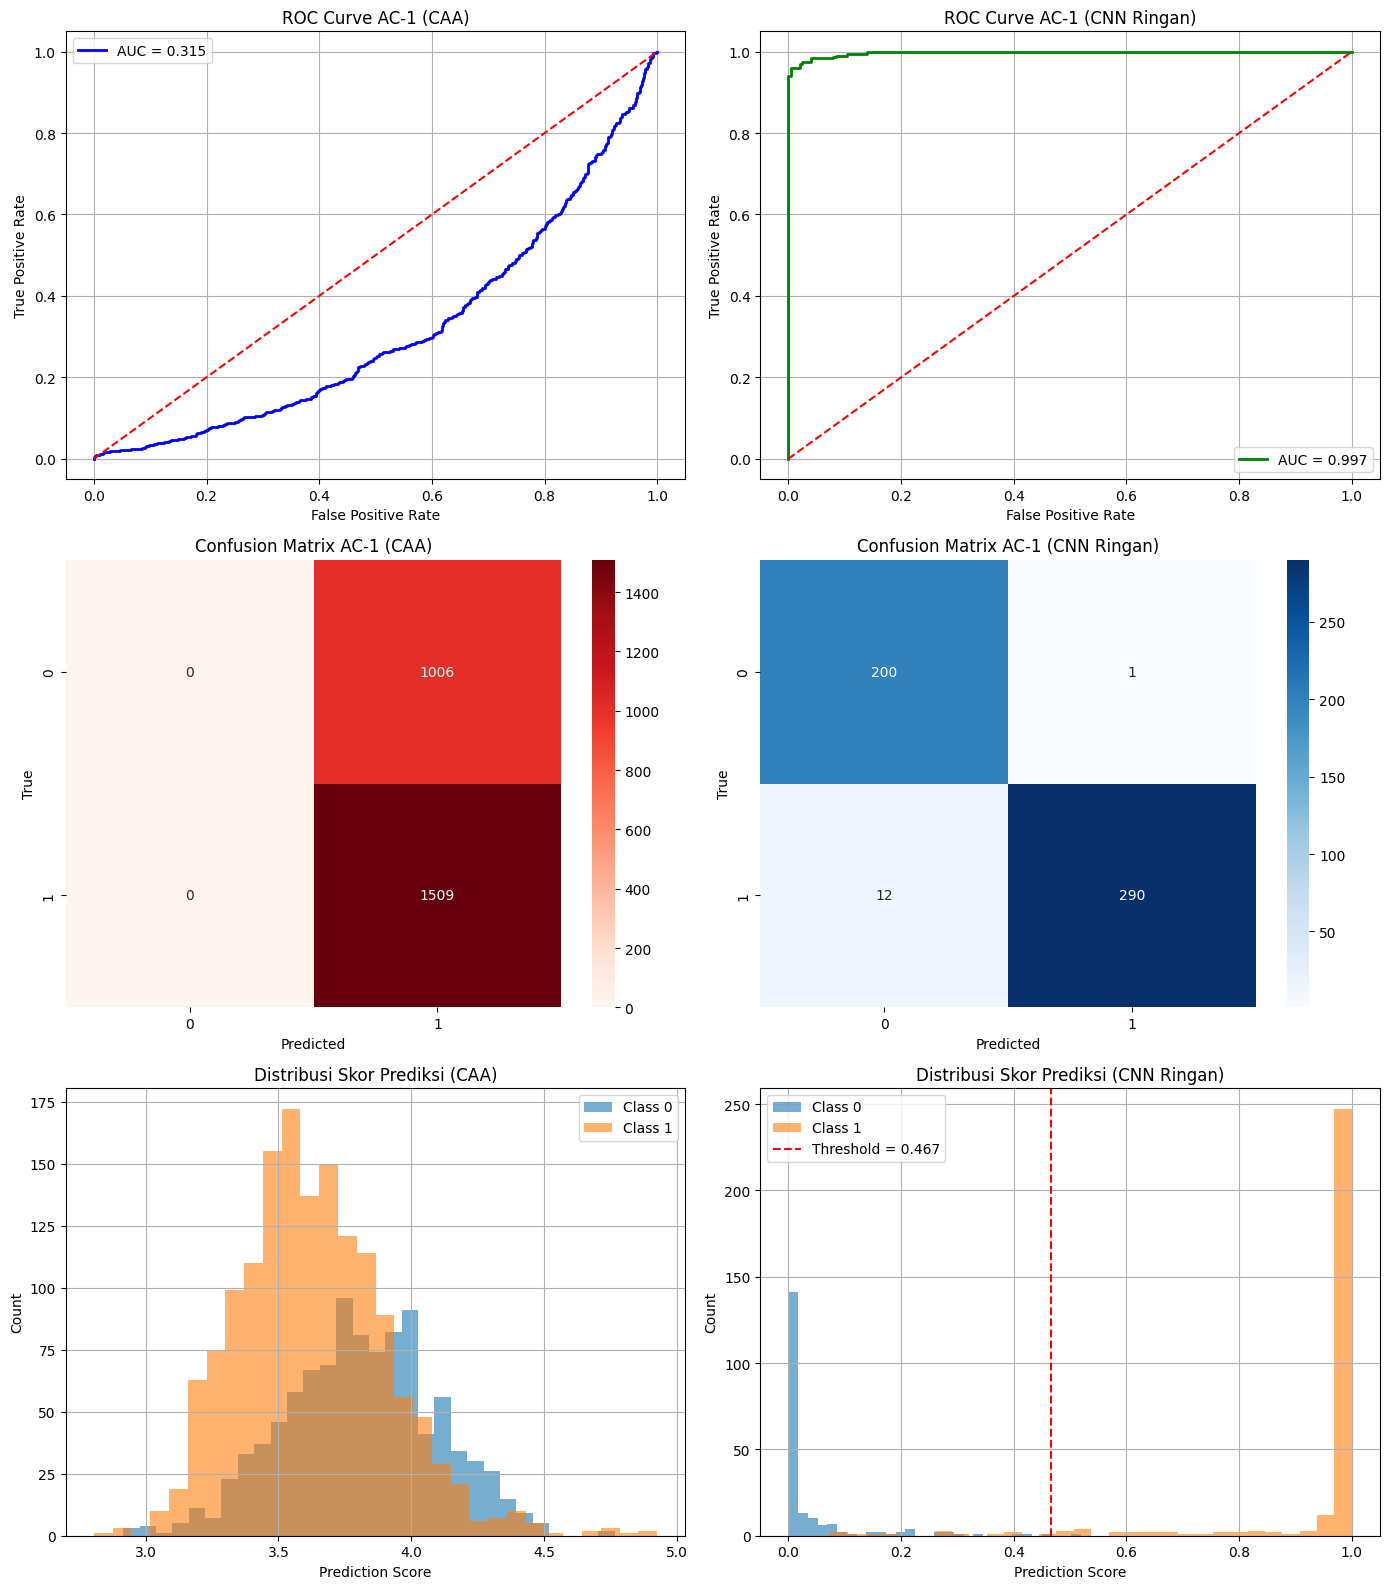

In [39]:
# Caption: Visualisasi lengkap perbandingan CAA vs CNN Ringan (ROC, CM, Histogram) dalam satu canvas 3×2
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(3, 2, figsize=(14, 16))

# ============================
# 1) ROC Curve CAA
# ============================
ax[0,0].plot(fpr_caa, tpr_caa, color='blue', lw=2, label=f"AUC = {auc_caa:.3f}")
ax[0,0].plot([0,1], [0,1], color='red', linestyle='--')
ax[0,0].set_title("ROC Curve AC-1 (CAA)")
ax[0,0].set_xlabel("False Positive Rate")
ax[0,0].set_ylabel("True Positive Rate")
ax[0,0].legend()
ax[0,0].grid(True)

# ============================
# 2) ROC Curve CNN Ringan
# ============================
ax[0,1].plot(fpr_cnn, tpr_cnn, color='green', lw=2, label=f"AUC = {auc_cnn:.3f}")
ax[0,1].plot([0,1], [0,1], color='red', linestyle='--')
ax[0,1].set_title("ROC Curve AC-1 (CNN Ringan)")
ax[0,1].set_xlabel("False Positive Rate")
ax[0,1].set_ylabel("True Positive Rate")
ax[0,1].legend()
ax[0,1].grid(True)

# ============================
# 3) Confusion Matrix CAA
# ============================
sns.heatmap(cm_caa, annot=True, fmt="d", cmap="Reds", ax=ax[1,0])
ax[1,0].set_title("Confusion Matrix AC-1 (CAA)")
ax[1,0].set_xlabel("Predicted")
ax[1,0].set_ylabel("True")

# ============================
# 4) Confusion Matrix CNN Ringan
# ============================
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", ax=ax[1,1])
ax[1,1].set_title("Confusion Matrix AC-1 (CNN Ringan)")
ax[1,1].set_xlabel("Predicted")
ax[1,1].set_ylabel("True")

# ============================
# 5) Distribusi Skor CAA
# ============================
ax[2,0].hist(score_caa[y_true==0], bins=30, alpha=0.6, label="Class 0")
ax[2,0].hist(score_caa[y_true==1], bins=30, alpha=0.6, label="Class 1")
ax[2,0].set_title("Distribusi Skor Prediksi (CAA)")
ax[2,0].set_xlabel("Prediction Score")
ax[2,0].set_ylabel("Count")
ax[2,0].legend()
ax[2,0].grid(True)

# ============================
# 6) Distribusi Skor CNN Ringan
# ============================
ax[2,1].hist(score_cnn[y_val==0], bins=30, alpha=0.6, label="Class 0")
ax[2,1].hist(score_cnn[y_val==1], bins=30, alpha=0.6, label="Class 1")
ax[2,1].axvline(best_th, color='red', linestyle='--', label=f"Threshold = {best_th:.3f}")
ax[2,1].set_title("Distribusi Skor Prediksi (CNN Ringan)")
ax[2,1].set_xlabel("Prediction Score")
ax[2,1].set_ylabel("Count")
ax[2,1].legend()
ax[2,1].grid(True)

plt.tight_layout()
plt.show()


In [2]:
# 1. Melihat grup utama (label) yang ada di dalam file HDF5
print("Daftar Label/Grup utama dalam file H5:")
labels = list(h5f.keys())
print(labels)

# 2. Melihat struktur data di dalam salah satu grup (misal grup pertama)
if len(labels) > 0:
    first_label = labels[0]
    print(f"\nContoh isi di dalam grup '{first_label}':")
    # Menampilkan 5 contoh nama trace/data pertama
    print(list(h5f[first_label].keys())[:5])

# 3. Melihat kolom apa saja yang ada di file CSV (Metadata)
print("\nKolom (Label Metadata) yang tersedia di CSV:")
print(df.columns.tolist())

Daftar Label/Grup utama dalam file H5:
['data']

Contoh isi di dalam grup 'data':
['109C.TA_20060723155859_EV', '109C.TA_20061103155652_EV', '109C.TA_20061103161223_EV', '109C.TA_20061114133221_EV', '109C.TA_20061127104640_EV']

Kolom (Label Metadata) yang tersedia di CSV:
['network_code', 'receiver_code', 'receiver_type', 'receiver_latitude', 'receiver_longitude', 'receiver_elevation_m', 'p_arrival_sample', 'p_status', 'p_weight', 'p_travel_sec', 's_arrival_sample', 's_status', 's_weight', 'source_id', 'source_origin_time', 'source_origin_uncertainty_sec', 'source_latitude', 'source_longitude', 'source_error_sec', 'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_depth_km', 'source_depth_uncertainty_km', 'source_magnitude', 'source_magnitude_type', 'source_magnitude_author', 'source_mechanism_strike_dip_rake', 'source_distance_deg', 'source_distance_km', 'back_azimuth_deg', 'snr_db', 'coda_end_sample', 'trace_start_time', 'trace_category', 'trace_name']


Menampilkan data untuk trace: A16.CN_20150121053158_EV


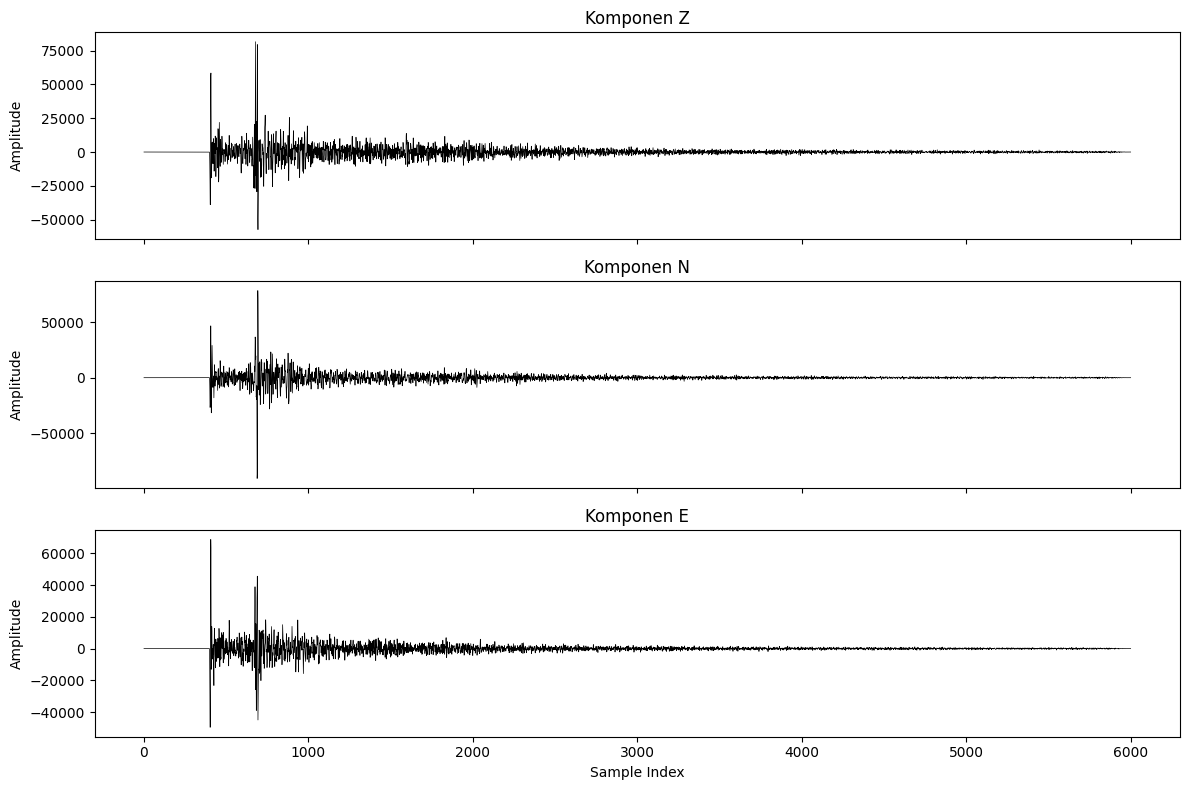

In [3]:
import matplotlib.pyplot as plt

# 1. Pilih satu contoh trace dari data yang sudah difilter (misal baris pertama)
sample_trace_name = df_nf.iloc[0]['trace_name']
print(f"Menampilkan data untuk trace: {sample_trace_name}")

# 2. Ambil data dari file H5
# Pastikan path-nya benar: h5f['nama_grup']['nama_dataset']
data_gelombang = h5f['data'][sample_trace_name]

# Konversi ke numpy array (biasanya bentuknya (3, jumlah_sample))
data_array = np.array(data_gelombang)

# 3. Visualisasi 3 komponen (Z, N, E)
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

komponen = ['Komponen Z', 'Komponen N', 'Komponen E']
for i in range(3):
    ax[i].plot(data_array[:, i], color='black', linewidth=0.5)
    ax[i].set_ylabel('Amplitude')
    ax[i].set_title(komponen[i])

ax[2].set_xlabel('Sample Index')
plt.tight_layout()
plt.show()

In [5]:
# 1. Pilih satu nama label/trace dari list yang kita dapat tadi
# Saya menggunakan index [0] dari hasil filter kamu (df_nf)
sample_name = df_nf.iloc[0]['trace_name']
dataset = h5f['data'][sample_name]

print(f"--- Eksplorasi Label: {sample_name} ---")

# 2. Menampilkan dimensi data
print(f"Bentuk Data (Shape): {dataset.shape}")
print(f"Tipe Data: {dataset.dtype}")

# 3. Menampilkan isi atribut (Metadata internal di dalam H5 jika ada)
print("\nAtribut yang tersimpan di label ini:")
if len(dataset.attrs) == 0:
    print("Tidak ada atribut tambahan di dalam dataset ini.")
else:
    for attr_name, attr_value in dataset.attrs.items():
        print(f"- {attr_name}: {attr_value}")

# 4. Menampilkan cuplikan data (5 sampel pertama, 3 komponen)
data_array = np.array(dataset)
print("\nCuplikan isi data (5 sampel pertama, 3 komponen):")
print(data_array[:5])

--- Eksplorasi Label: A16.CN_20150121053158_EV ---
Bentuk Data (Shape): (6000, 3)
Tipe Data: float32

Atribut yang tersimpan di label ini:
- back_azimuth_deg: 56.900001525878906
- coda_end_sample: [[1228.]]
- network_code: CN
- p_arrival_sample: 400.0
- p_status: manual
- p_travel_sec: 4.630000114440918
- p_weight: 0.5
- receiver_code: A16
- receiver_elevation_m: 13.0
- receiver_latitude: 47.468
- receiver_longitude: -70.0096
- receiver_type: HH
- s_arrival_sample: 686.0
- s_status: manual
- s_weight: 0.5
- snr_db: [72.40000153 61.70000076 62.20000076]
- source_depth_km: 17.420000076293945
- source_depth_uncertainty_km: 7.599999904632568
- source_distance_deg: 0.18000000715255737
- source_distance_km: 19.209999084472656
- source_error_sec: 0.8797000050544739
- source_gap_deg: 37.69900131225586
- source_horizontal_uncertainty_km: 2.6865499019622803
- source_id: 606589340
- source_latitude: 47.3748
- source_longitude: -70.2239
- source_magnitude: 3.7
- source_magnitude_author: None
- sou

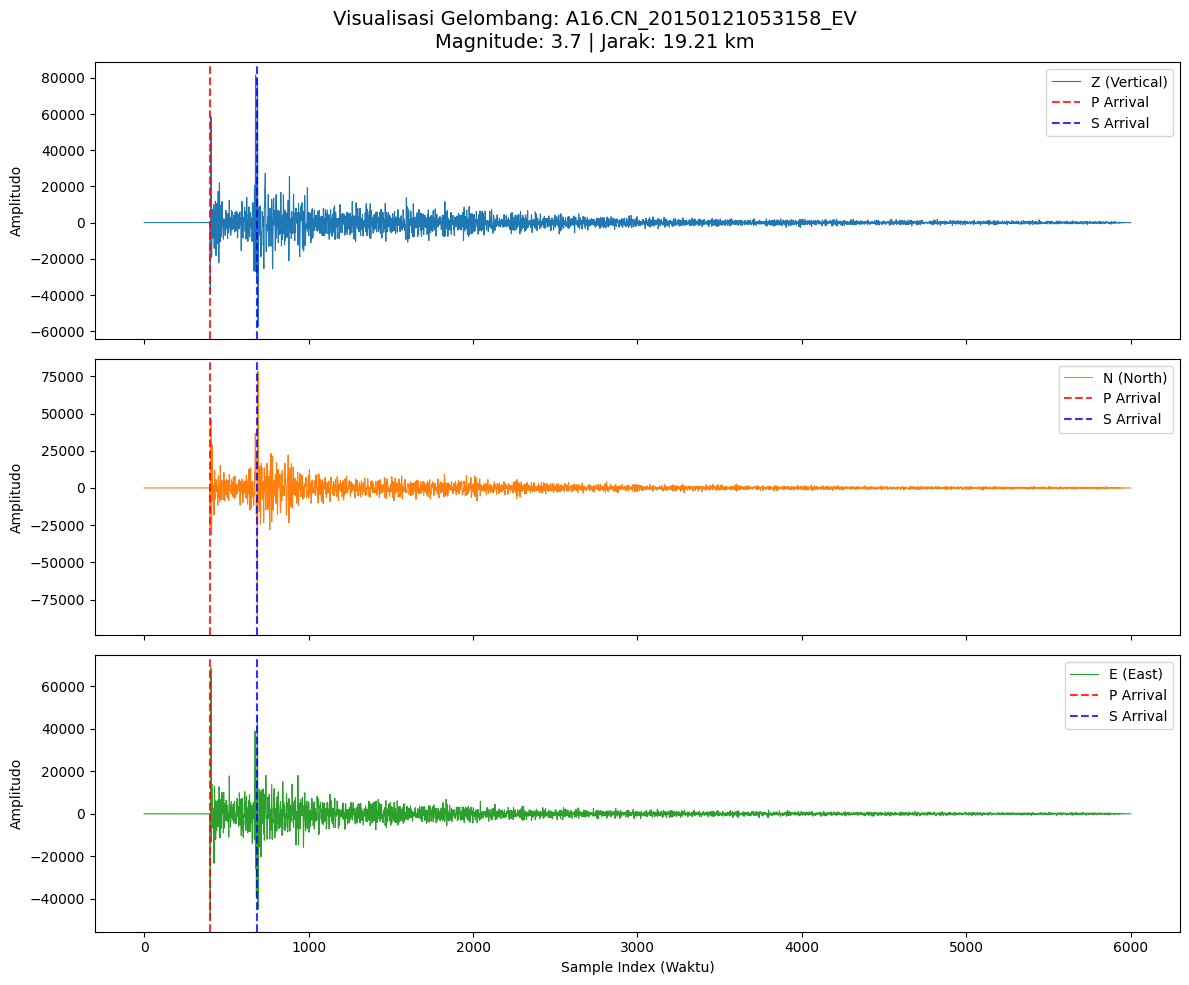

In [6]:
import matplotlib.pyplot as plt

# 1. Ambil data gelombang dan atributnya
data_array = np.array(h5f['data'][sample_name])
p_idx = dataset.attrs['p_arrival_sample']
s_idx = dataset.attrs['s_arrival_sample']

# 2. Plotting
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Warna berbeda untuk tiap komponen
labels = ['Z (Vertical)', 'N (North)', 'E (East)']

for i in range(3):
    ax[i].plot(data_array[:, i], color=colors[i], label=labels[i], linewidth=0.8)
    
    # Menambahkan garis vertikal untuk P dan S arrival
    ax[i].axvline(x=p_idx, color='red', linestyle='--', alpha=0.8, label='P Arrival')
    ax[i].axvline(x=s_idx, color='blue', linestyle='--', alpha=0.8, label='S Arrival')
    
    ax[i].legend(loc='upper right')
    ax[i].set_ylabel('Amplitudo')

ax[2].set_xlabel('Sample Index (Waktu)')
plt.suptitle(f"Visualisasi Gelombang: {sample_name}\nMagnitude: {dataset.attrs['source_magnitude']} | Jarak: {dataset.attrs['source_distance_km']:.2f} km", fontsize=14)
plt.tight_layout()
plt.show()